In [1]:
# --- Imports ---
import sys
sys.path.append("../src")  # so we can import our shared loader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import DataLoader

# Display settings — helpful when scanning many rows/trials
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
# --- Load and align the dataset ---
loader = DataLoader(data_dir="../data")

print(f"Total aligned trials: {len(loader)}")

Found 2160 signal files in ../data\MI CSV
[DataLoader] found 2400 labels and 2160 signal files.
DataLoader: Dropping last 240 extra labels to align with signal files.
[DataLoader] successfully aligned 2160 EEG trials with labels.
Total aligned trials: 2160


## First , let's inspect labels balance and sampling consistincy 

Class counts:
label
left     1082
right    1078
Name: count, dtype: int64

Class percentages:
label
left     50.09
right    49.91
Name: proportion, dtype: float64


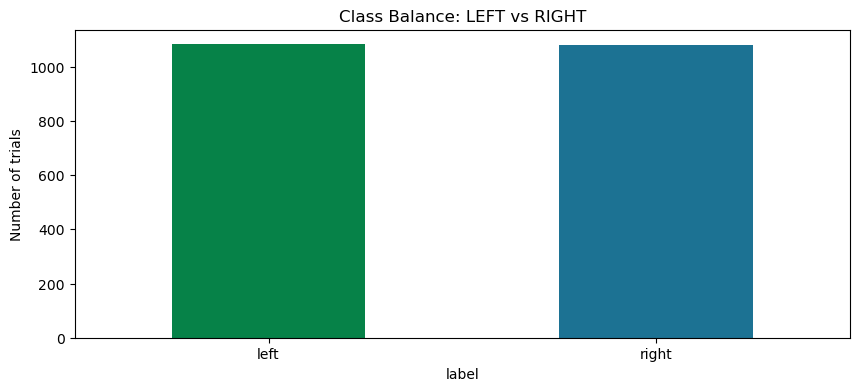

In [3]:
# --- Class balance check ---
label_counts = loader.valid_manifest["label"].value_counts()
label_percent = loader.valid_manifest["label"].value_counts(normalize=True) * 100

print("Class counts:")
print(label_counts)
print("\nClass percentages:")
print(label_percent.round(2))

label_counts.plot(kind="bar", color=["#068248", "#1C7293"])
plt.title("Class Balance: LEFT vs RIGHT")
plt.ylabel("Number of trials")
plt.xticks(rotation=0)
plt.show()

Min length: 2500
Max length: 2500
Most common length: 2500
Number of unique lengths: 1


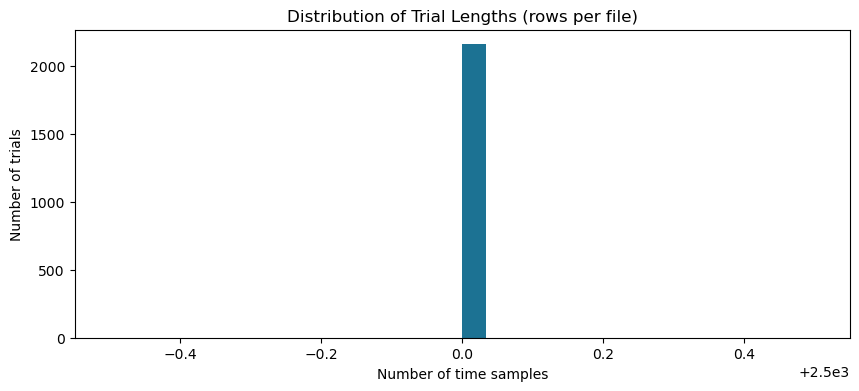

In [4]:
# --- Sampling rate & trial length consistency ---
lengths = []

for i in range(len(loader)):
    signal_df, _ = loader.load_trial(i)
    lengths.append(signal_df.shape[0])

lengths = np.array(lengths)

print(f"Min length: {lengths.min()}")
print(f"Max length: {lengths.max()}")
print(f"Most common length: {pd.Series(lengths).mode()[0]}")
print(f"Number of unique lengths: {len(np.unique(lengths))}")

plt.hist(lengths, bins=30, color="#1C7293")
plt.title("Distribution of Trial Lengths (rows per file)")
plt.xlabel("Number of time samples")
plt.ylabel("Number of trials")
plt.show()

## Time sampling reading jumbs check 

In [5]:
signal_df, label = loader.load_trial(0)
print(signal_df.columns.tolist())
print(signal_df.head())

['Time', 'FZ', 'C3', 'CZ', 'C4']
           Time            FZ            C3            CZ            C4
0  88451.201876  324761.37500  321002.62500  335287.28125  321417.90625
1  88451.221777  325001.18750  321223.09375  335409.56250  320937.09375
2  88451.221788  324896.75000  321045.53125  334954.40625  320233.56250
3  88451.229576  324627.28125  320756.12500  334589.43750  320262.25000
4  88451.229588  324538.31250  320729.21875  334804.56250  321010.50000


count    2499.000000
mean        0.003999
std         0.006706
min         0.000002
25%         0.001650
50%         0.002493
75%         0.003702
max         0.072636
Name: Time, dtype: float64


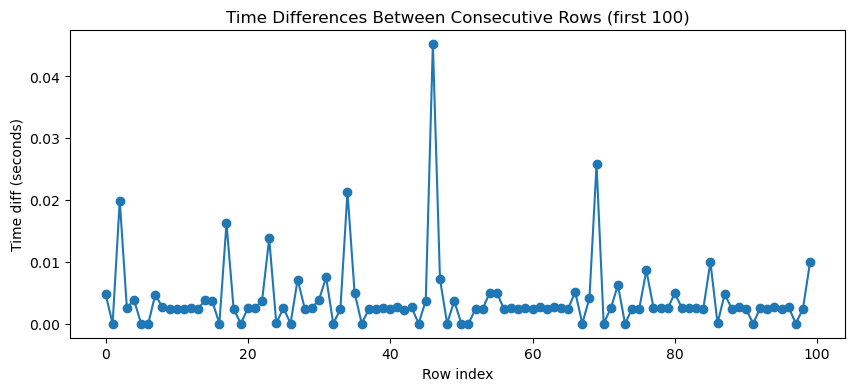

In [6]:
signal_df, label = loader.load_trial(1)

time_diffs = signal_df["Time"].diff().dropna()

print(time_diffs.describe())

plt.plot(time_diffs.values[:100], marker="o")
plt.title("Time Differences Between Consecutive Rows (first 100)")
plt.xlabel("Row index")
plt.ylabel("Time diff (seconds)")
plt.show()

## NaNs check 

In [7]:
# --- NaN / missing values check ---
nan_summary = []

for i in range(len(loader)):
    signal_df, label = loader.load_trial(i)
    n_nans = signal_df.isna().sum().sum()
    if n_nans > 0:
        nan_summary.append({"trial_id": loader.valid_manifest.iloc[i]["trial_id"],
                             "label": label,
                             "n_nans": n_nans})

print(f"Trials with at least one NaN: {len(nan_summary)} out of {len(loader)}")

if nan_summary:
    nan_df = pd.DataFrame(nan_summary)
    display(nan_df.head(10))
else:
    print("No NaNs found across the dataset.")

Trials with at least one NaN: 0 out of 2160
No NaNs found across the dataset.


## Ploting raw C3 / C4 signals 

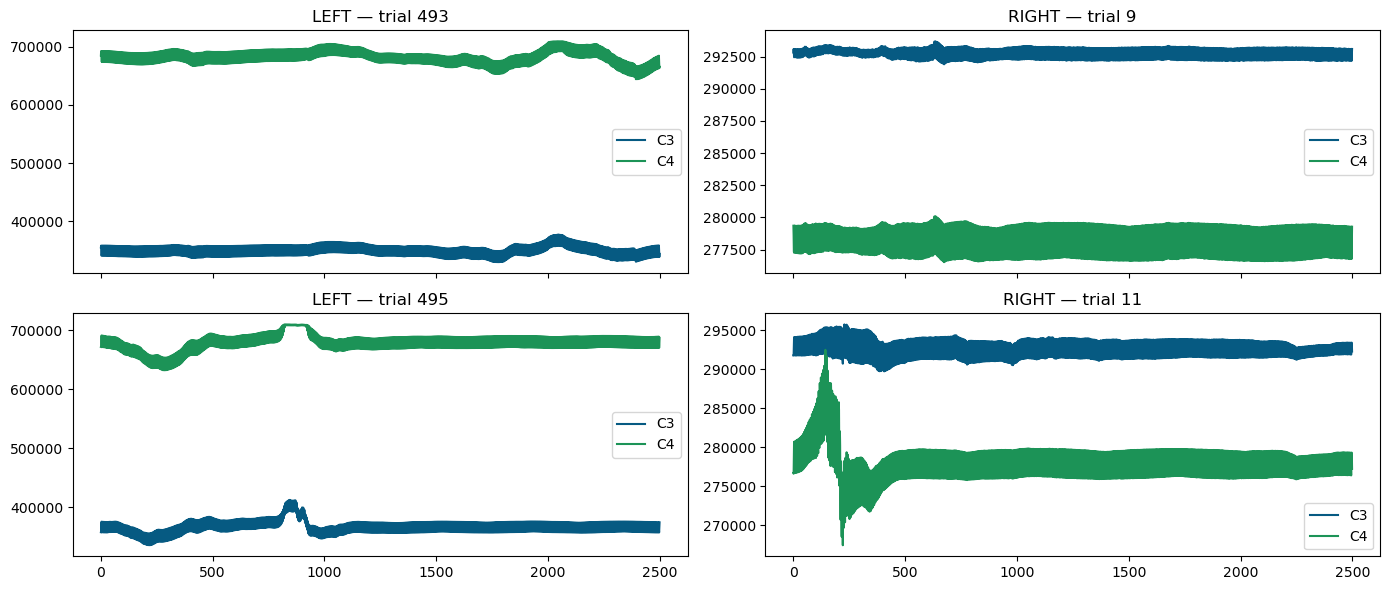

In [8]:
# --- Raw signal plots: LEFT vs RIGHT on C3 and C4 ---

# Grab a few LEFT and RIGHT trial indices
left_idx = loader.valid_manifest[loader.valid_manifest["label"] == "left"].index[256:258]
right_idx = loader.valid_manifest[loader.valid_manifest["label"] == "right"].index[3:5]

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)

for col, idx_group, title in zip([0, 1], [left_idx, right_idx], ["LEFT", "RIGHT"]):
    for row, idx in enumerate(idx_group):
        signal_df, label = loader.load_trial(idx)
        axes[row, col].plot(signal_df["C3"], label="C3", color="#065A82")
        axes[row, col].plot(signal_df["C4"], label="C4", color="#1C9357")
        axes[row, col].set_title(f"{title} — trial {idx}")
        axes[row, col].legend()

plt.tight_layout()
plt.show()

## Investigating this noisy channels issue 

count    2160.000000
mean        0.726328
std         0.474533
min        -0.947906
25%         0.712467
50%         0.942526
75%         0.989040
max         0.999939
Name: c3_c4_corr, dtype: float64


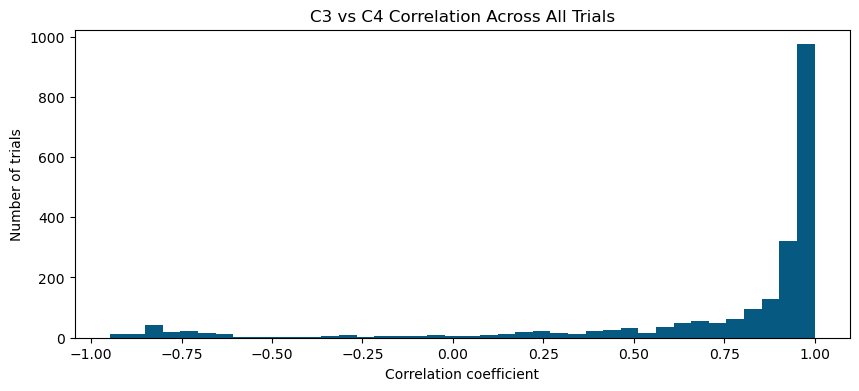


Trials with C3/C4 correlation > 0.95: 987


,trial_id,label,c3_c4_corr
10,11,left,0.962489
12,13,left,0.997328
13,14,left,0.987992
14,15,left,0.984043
15,16,right,0.993457
16,17,right,0.994348
17,18,left,0.996754
64,65,left,0.979513
65,66,right,0.957555
66,67,right,0.979711


In [9]:
# --- Check C3/C4 similarity across all trials ---
correlations = []

for i in range(len(loader)):
    signal_df, label = loader.load_trial(i)
    corr = signal_df["C3"].corr(signal_df["C4"])
    correlations.append({"trial_id": loader.valid_manifest.iloc[i]["trial_id"],
                          "label": label,
                          "c3_c4_corr": corr})

corr_df = pd.DataFrame(correlations)

print(corr_df["c3_c4_corr"].describe())

plt.hist(corr_df["c3_c4_corr"], bins=40, color="#065A82")
plt.title("C3 vs C4 Correlation Across All Trials")
plt.xlabel("Correlation coefficient")
plt.ylabel("Number of trials")
plt.show()

# Flag suspiciously high-correlation trials (near-duplicate channels)
suspicious = corr_df[corr_df["c3_c4_corr"] > 0.95]
print(f"\nTrials with C3/C4 correlation > 0.95: {len(suspicious)}")
display(suspicious.head(10))

label
left     495
right    492
Name: count, dtype: int64


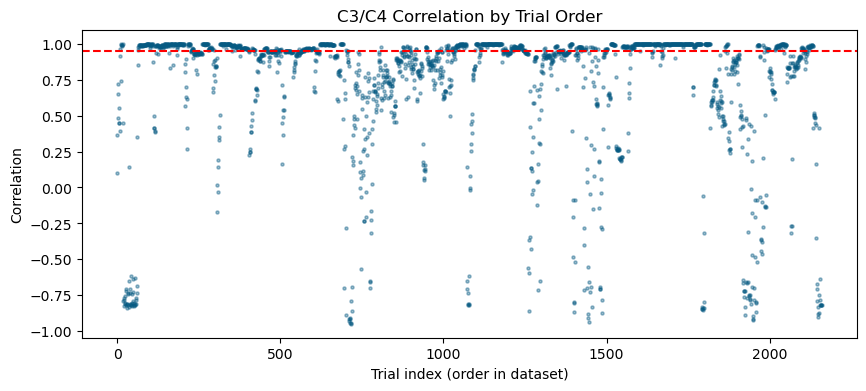

In [10]:
# Does high correlation cluster by label?
suspicious_labels = corr_df[corr_df["c3_c4_corr"] > 0.95]["label"].value_counts()
print(suspicious_labels)

# Does high correlation cluster by trial order (e.g., early vs late trials)?
plt.scatter(corr_df.index, corr_df["c3_c4_corr"], s=5, alpha=0.4, color="#065A82")
plt.axhline(0.95, color="red", linestyle="--")
plt.title("C3/C4 Correlation by Trial Order")
plt.xlabel("Trial index (order in dataset)")
plt.ylabel("Correlation")
plt.show()

In [11]:
import pandas as pd
import numpy as np

channels = ["FZ", "C3", "CZ", "C4"]

channel_stats = []

for i in range(len(loader)):

    signal_df, label = loader.load_trial(i)

    trial_id = loader.valid_manifest.iloc[i]["trial_id"]

    for channel in channels:

        values = signal_df[channel].values

        channel_stats.append({
            "trial_id": trial_id,
            "label": label,
            "channel": channel,

            "mean": np.mean(values),
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values),
            "peak_to_peak": np.ptp(values)
        })


stats_df = pd.DataFrame(channel_stats)

stats_df.head()

,trial_id,label,channel,mean,std,min,max,peak_to_peak
0,1,left,FZ,324770.376525,182.328861,324489.78125,325086.75000,596.96875
1,1,left,C3,320966.199350,181.360512,320697.84375,321280.68750,582.84375
2,1,left,CZ,334986.259500,281.379692,334553.15625,335460.71875,907.56250
3,1,left,C4,320801.713538,428.455625,320128.68750,321480.06250,1351.37500
4,2,right,FZ,324826.075063,157.600588,324489.93750,325136.00000,646.06250


In [12]:
summary = stats_df.groupby("channel").agg({
    "mean": "mean",
    "std": "mean",
    "min": "min",
    "max": "max",
    "peak_to_peak": "mean"
})

summary

,mean,std,min,max,peak_to_peak
channel,,,,,
C3,301785.962102,973.761420,222394.406250,456487.46875,3606.327915
C4,326867.923182,1451.481138,205573.828125,710464.37500,5075.571810
CZ,334266.652415,2026.444331,236736.546875,710274.37500,6917.631221
FZ,298497.903373,1267.297757,225946.375000,456689.25000,4108.419654


In [13]:
artifact_records = []

for i in range(len(loader)):

    signal_df, label = loader.load_trial(i)

    trial_id = loader.valid_manifest.iloc[i]["trial_id"]

    for channel in channels:

        values = signal_df[channel]

        artifact_records.append({
            "trial_id": trial_id,
            "label": label,
            "channel": channel,
            "has_nan": values.isna().any(),
            "std": values.std(),
            "peak_to_peak": values.max() - values.min()
        })

artifact_df = pd.DataFrame(artifact_records)

## Detecting flat channels 

In [14]:
artifact_df["flat_channel"] = artifact_df["std"] < 1e-8
artifact_df["flat_channel"].sum()

np.int64(0)

### insight : No flat channels 

## Check extreme variablilty in the channels and Jumbs between readings

In [15]:
artifact_df["extreme_variability"] = False

for channel in channels:

    mask = artifact_df["channel"] == channel

    values = artifact_df.loc[mask, "peak_to_peak"]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    upper_limit = q3 + 3 * iqr

    artifact_df.loc[
        mask & (artifact_df["peak_to_peak"] > upper_limit),
        "extreme_variability"
    ] = True

In [16]:
artifact_df["extreme_variability"].value_counts()

extreme_variability
False    8242
True      398
Name: count, dtype: int64

In [17]:
# How many flagged instances per channel?
print(artifact_df[artifact_df["extreme_variability"]]["channel"].value_counts())

# How many UNIQUE trials have at least one flagged channel?
flagged_trials = artifact_df[artifact_df["extreme_variability"]]["trial_id"].nunique()
print(f"\nUnique trials with at least one extreme-variability channel: {flagged_trials}")
print(f"Out of {loader.valid_manifest['trial_id'].nunique()} total trials "
      f"({flagged_trials / loader.valid_manifest['trial_id'].nunique() * 100:.1f}%)")

channel
CZ    134
FZ    115
C3     78
C4     71
Name: count, dtype: int64

Unique trials with at least one extreme-variability channel: 187
Out of 2160 total trials (8.7%)


In [18]:
# Detect abrupt jumps within a single trial (possible electrode pop mid-recording)
def max_jump(series):
    return series.diff().abs().max()

jump_records = []
for i in range(len(loader)):
    signal_df, label = loader.load_trial(i)
    trial_id = loader.valid_manifest.iloc[i]["trial_id"]
    for ch in channels:
        jump_records.append({"trial_id": trial_id, "channel": ch, "max_jump": max_jump(signal_df[ch])})

jump_df = pd.DataFrame(jump_records)
jump_df.groupby("channel")["max_jump"].describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
C3,2160.0,1786.489142,2491.871622,33.343750,353.718750,899.093750,2524.687500,21071.0625
C4,2160.0,2504.692585,2581.275104,61.421875,831.812500,1583.765625,3748.953125,22807.1875
CZ,2160.0,3663.300998,6230.955101,88.343750,874.914062,1792.937500,3397.750000,45747.1250
FZ,2160.0,2327.330548,4034.866881,59.656250,424.687500,741.640625,2616.890625,32279.8750


In [19]:
jump_threshold_flags = []

for ch in channels:
    values = jump_df[jump_df["channel"] == ch]["max_jump"]
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr
    flagged = jump_df[(jump_df["channel"] == ch) & (jump_df["max_jump"] > upper)]
    jump_threshold_flags.append(flagged)

jump_flagged_df = pd.concat(jump_threshold_flags)
print(f"Total flagged jump instances: {len(jump_flagged_df)}")
print(jump_flagged_df["channel"].value_counts())

# Do these overlap with your earlier extreme_variability flagged trials?
overlap = set(jump_flagged_df["trial_id"]) & set(flagged["trial_id"])
print(f"\nTrials flagged by BOTH peak-to-peak AND max-jump: {len(overlap)}")

Total flagged jump instances: 341
channel
CZ    111
FZ     94
C3     79
C4     57
Name: count, dtype: int64

Trials flagged by BOTH peak-to-peak AND max-jump: 57


In [20]:
# Does the 57-trial high-confidence group skew toward one label?
overlap_ids = set(jump_flagged_df["trial_id"]) & set(flagged["trial_id"])
overlap_labels = loader.valid_manifest[loader.valid_manifest["trial_id"].isin(overlap_ids)]["label"]
print(overlap_labels.value_counts())

label
left     29
right    28
Name: count, dtype: int64


In [21]:
# Add to the END of notebook 1 — saves flagged results for reuse
artifact_df.to_csv("../data/artifact_flags.csv", index=False)
jump_df.to_csv("../data/jump_flags.csv", index=False)